# C-MAPSS Modeling — `modeling_v2` · LSTM baseline (tightened) on FD001

**Course project:** 24-788 Introduction to Deep Learning (Spring 2026), 2-person team  
**This notebook:** the **tightened baseline** — three targeted fixes over `modeling_v1`:

1. **Early stopping** (`patience=10`) — stops training when val RMSE has not improved for 10 consecutive epochs, preventing the overfitting observed at epoch 18 in v1.
2. **Reduced epoch budget** (`N_EPOCHS=40`) — best val in v1 was epoch 18; 40 epochs with early stopping is a comfortable ceiling that avoids wasted compute.
3. **Raised RUL clip** (`RUL_CLIP=130`) — gives the model 5 extra cycles of headroom to predict the upper tail of the test distribution (11% of test engines had true RUL > 125 in v1's analysis), without sacrificing the focusing benefit of clipping.

Everything else is identical to `modeling_v1`: same architecture (2-layer LSTM, hidden=64, dropout=0.3), same data pipeline, same live `TrainTracker`, same evaluation protocol (RMSE + PHM asymmetric score on un-clipped test labels).

**Hardware target:** Apple Silicon (MPS), with CUDA / CPU fallback.  
**Time budget:** ~6-8 minutes on an M4 MacBook Pro (shorter due to early stopping).


## 1 · Setup

**Dependencies.** If running locally for the first time, install these in your environment:

```bash
pip install torch numpy pandas matplotlib seaborn tqdm jupyter ipykernel
```

`torch` on Apple Silicon ships with MPS support out of the box (no special wheel needed). All other libs are stock scientific Python.

Place the unzipped `CMAPSSData/` folder next to this notebook before running.


In [1]:
import os, time, random, math, json
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from IPython.display import display, clear_output

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device pattern: cuda -> mps -> cpu
if torch.cuda.is_available():
    Device = "cuda"
elif torch.backends.mps.is_available():
    Device = "mps"
else:
    Device = "cpu"
print(f"Device : {Device}")
print(f"PyTorch: {torch.__version__}")

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("CMAPSSData")
CKPT_DIR = Path("checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
FIG_DIR  = Path("figures");     FIG_DIR.mkdir(exist_ok=True)

assert DATA_DIR.exists(), "Place CMAPSSData/ next to this notebook (or edit DATA_DIR)."

Device : mps
PyTorch: 2.11.0


## 2 · Data loading and preprocessing

Identical to `modeling_v1` except for `RUL_CLIP=130` (raised from 125).

We load FD001 train + test, build the RUL labels for the train trajectories, drop the flat sensors identified in EDA, then z-score the remaining sensors using statistics computed **on the training set only**. The test set uses the same statistics (no peeking).


In [2]:
COLS = (["unit", "cycle", "setting_1", "setting_2", "setting_3"]
        + [f"s_{i}" for i in range(1, 22)])
SENSORS_ALL = [c for c in COLS if c.startswith("s_")]

# From eda_v1 §5: flat sensors + s_6 (low RUL correlation, near-discrete).
DROP_SENSORS = ["s_1", "s_5", "s_6", "s_10", "s_16", "s_18", "s_19"]
USE_SENSORS  = [s for s in SENSORS_ALL if s not in DROP_SENSORS]
print(f"Using {len(USE_SENSORS)} sensors: {USE_SENSORS}")

W        = 30   # sliding window length (from EDA)
RUL_CLIP = 130  # raised from 125: gives 5 extra cycles of headroom in the upper tail
SUBSET   = "FD001"

def load_subset(subset: str):
    train = pd.read_csv(DATA_DIR / f"train_{subset}.txt", sep=r"\s+",
                        header=None, names=COLS, engine="python")
    test  = pd.read_csv(DATA_DIR / f"test_{subset}.txt",  sep=r"\s+",
                        header=None, names=COLS, engine="python")
    rul   = pd.read_csv(DATA_DIR / f"RUL_{subset}.txt",   sep=r"\s+",
                        header=None, names=["RUL"],    engine="python")["RUL"].values
    return train, test, rul

train_df, test_df, true_rul = load_subset(SUBSET)
print(f"{SUBSET}: train rows={len(train_df):,}, test rows={len(test_df):,}, "
      f"train engines={train_df['unit'].nunique()}, test engines={test_df['unit'].nunique()}")

Using 14 sensors: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
FD001: train rows=20,631, test rows=13,096, train engines=100, test engines=100


In [3]:
def add_rul(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    df["RUL"] = max_cycle - df["cycle"]
    return df

train_df = add_rul(train_df)

# Train-only normalization stats
train_means = train_df[USE_SENSORS].mean()
train_stds  = train_df[USE_SENSORS].std().replace(0, 1.0)

def normalize(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df[USE_SENSORS] = (df[USE_SENSORS] - train_means) / train_stds
    return df

train_df = normalize(train_df)
test_df  = normalize(test_df)

print("Train RUL stats (un-clipped):",
      f"mean={train_df['RUL'].mean():.1f}, max={train_df['RUL'].max()}")
print(f"After clipping at {RUL_CLIP} -> "
      f"mean={train_df['RUL'].clip(upper=RUL_CLIP).mean():.1f}")
print("Sensor stats after normalization (should be ~0 mean, ~1 std):")
print(train_df[USE_SENSORS].describe().loc[["mean","std"]].T.round(3).head(8))

Train RUL stats (un-clipped): mean=107.8, max=361
After clipping at 130 -> mean=88.7
Sensor stats after normalization (should be ~0 mean, ~1 std):
      mean  std
s_2    0.0  1.0
s_3   -0.0  1.0
s_4    0.0  1.0
s_7   -0.0  1.0
s_8    0.0  1.0
s_9   -0.0  1.0
s_11  -0.0  1.0
s_12  -0.0  1.0


## 3 · Sliding-window `Dataset`

For each training engine with trajectory length L >= W, we generate (L - W + 1) windows of shape (W, n_features), each labeled with the RUL **at the last cycle of the window**. Engines shorter than W are dropped (none on FD001 train).

For the test set, each engine contributes **one** window -- the final W cycles of its truncated trajectory -- and the label is the corresponding entry from `RUL_FD001.txt`. Engines with fewer than W observed cycles are front-padded by repeating the earliest cycle.


In [4]:
class CMAPSSWindowDataset(Dataset):
    """Sliding-window dataset for training. One sample per (engine, end_cycle) pair."""
    def __init__(self, df: pd.DataFrame, sensors, window: int, rul_clip: int):
        self.window  = window
        self.sensors = sensors
        self.X = []
        self.y = []
        for _, eng in df.groupby("unit"):
            sensor_array = eng[sensors].values.astype(np.float32)
            rul_array    = np.minimum(eng["RUL"].values.astype(np.float32), rul_clip)
            L = len(eng)
            if L < window:
                continue
            for end in range(window, L + 1):
                self.X.append(sensor_array[end - window : end])
                self.y.append(rul_array[end - 1])
        self.X = np.stack(self.X)
        self.y = np.array(self.y, dtype=np.float32)

    def __len__(self):  return len(self.X)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), torch.tensor(self.y[i])


def build_test_windows(df: pd.DataFrame, sensors, window: int):
    """One window per test engine: last `window` cycles, front-padded if needed."""
    Xs = []
    for unit, eng in df.groupby("unit"):
        arr = eng[sensors].values.astype(np.float32)
        if len(arr) >= window:
            Xs.append(arr[-window:])
        else:
            pad = np.tile(arr[0:1], (window - len(arr), 1))
            Xs.append(np.concatenate([pad, arr], axis=0))
    return np.stack(Xs)


# 80/20 engine-level train/val split
rng = np.random.default_rng(SEED)
all_units = train_df["unit"].unique()
val_units = rng.choice(all_units, size=int(0.2 * len(all_units)), replace=False)
val_mask  = train_df["unit"].isin(val_units)

train_set = CMAPSSWindowDataset(train_df[~val_mask], USE_SENSORS, W, RUL_CLIP)
val_set   = CMAPSSWindowDataset(train_df[ val_mask], USE_SENSORS, W, RUL_CLIP)

X_test = build_test_windows(test_df, USE_SENSORS, W)
y_test = true_rul.astype(np.float32)

print(f"Train windows: {len(train_set):,}  (from {len(all_units) - len(val_units)} engines)")
print(f"Val   windows: {len(val_set):,}  (from {len(val_units)} engines)")
print(f"Test  windows: {X_test.shape[0]:,}  (one per test engine)")
print(f"Window shape : (W={W}, F={len(USE_SENSORS)})")

Train windows: 14,070  (from 80 engines)
Val   windows: 3,661  (from 20 engines)
Test  windows: 100  (one per test engine)
Window shape : (W=30, F=14)


## 4 · LSTM model

Unchanged from `modeling_v1`:

- 2-layer LSTM, hidden size 64
- Dropout 0.3 between layers + 0.3 before the head
- Last hidden state -> FC head (64 -> 32 -> 1)
- ~30k parameters


In [5]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features: int, hidden: int = 64, num_layers: int = 2,
                 dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):                   # x: (B, W, F)
        out, _ = self.lstm(x)               # (B, W, H)
        last   = out[:, -1, :]             # (B, H)
        return self.head(last).squeeze(-1)  # (B,)


_n_feat = len(USE_SENSORS)
_model  = LSTMRegressor(_n_feat).to(Device)
_x      = torch.randn(8, W, _n_feat, device=Device)
_y      = _model(_x)
print(f"Output shape: {tuple(_y.shape)}  (expected (8,))")
print(f"Total params: {sum(p.numel() for p in _model.parameters()):,}")
del _model, _x, _y

Output shape: (8,)  (expected (8,))
Total params: 55,873


## 5 · Live training tracker

Same `GAN_Tracker`-style pattern as `modeling_v1`: two-subplot figure (loss + RMSE), updated per epoch via `clear_output(wait=True)` + `display(fig)`. The suptitle shows epoch / RMSEs / elapsed / ETA.

A vertical dashed line marks the **early-stop epoch** once training ends early.


In [6]:
class TrainTracker:
    """Live-updating per-epoch loss + RMSE plot."""

    def __init__(self, n_epochs: int, plot_freq: int = 1):
        self.n_epochs   = n_epochs
        self.plot_freq  = plot_freq
        self.epoch      = 0
        self.train_loss = []
        self.val_loss   = []
        self.train_rmse = []
        self.val_rmse   = []
        self.t0         = time.time()
        self._stopped_at = None  # filled in if early stopping fires
        self._init_fig()

    def _init_fig(self):
        plt.ioff()
        self.fig, (self.ax_loss, self.ax_rmse) = plt.subplots(1, 2, figsize=(13, 4))

        self.tl_curve, = self.ax_loss.plot([], [], label="train", color="steelblue")
        self.vl_curve, = self.ax_loss.plot([], [], label="val",   color="darkorange")
        self.ax_loss.set_xlim(0, self.n_epochs + 1)
        self.ax_loss.set_xlabel("Epoch")
        self.ax_loss.set_ylabel("MSE loss (clipped RUL)")
        self.ax_loss.set_title("Training loss")
        self.ax_loss.legend(); self.ax_loss.grid(linestyle="--", alpha=0.6)

        self.tr_curve, = self.ax_rmse.plot([], [], label="train", color="steelblue")
        self.vr_curve, = self.ax_rmse.plot([], [], label="val",   color="darkorange")
        self.ax_rmse.set_xlim(0, self.n_epochs + 1)
        self.ax_rmse.set_xlabel("Epoch")
        self.ax_rmse.set_ylabel("RMSE (cycles, clipped RUL)")
        self.ax_rmse.set_title("RMSE")
        self.ax_rmse.legend(); self.ax_rmse.grid(linestyle="--", alpha=0.6)

        plt.tight_layout()

    def update_epoch(self, train_loss: float, val_loss: float,
                     train_rmse: float, val_rmse: float):
        self.train_loss.append(train_loss)
        self.val_loss.append(val_loss)
        self.train_rmse.append(train_rmse)
        self.val_rmse.append(val_rmse)
        self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs:
            self._redraw()

    def mark_early_stop(self, epoch: int):
        """Call after the training loop if early stopping fired."""
        self._stopped_at = epoch

    def _redraw(self):
        xs = list(range(1, self.epoch + 1))
        self.tl_curve.set_data(xs, self.train_loss)
        self.vl_curve.set_data(xs, self.val_loss)
        self.tr_curve.set_data(xs, self.train_rmse)
        self.vr_curve.set_data(xs, self.val_rmse)
        self.ax_loss.relim(); self.ax_loss.autoscale_view()
        self.ax_rmse.relim(); self.ax_rmse.autoscale_view()

        # Draw early-stop marker if it has been set
        if self._stopped_at is not None:
            for ax in (self.ax_loss, self.ax_rmse):
                for line in ax.lines:
                    if getattr(line, "_early_stop", False):
                        line.remove()
                vl = ax.axvline(self._stopped_at, color="crimson", linestyle=":",
                                lw=1.5, label="early stop")
                vl._early_stop = True
            self.ax_loss.legend(fontsize=8)
            self.ax_rmse.legend(fontsize=8)

        elapsed = time.time() - self.t0
        per_ep  = elapsed / self.epoch
        eta     = per_ep * (self.n_epochs - self.epoch)
        suffix  = "  [early stop]" if self._stopped_at else ""
        title   = (f"Epoch {self.epoch}/{self.n_epochs}  ·  "
                   f"train RMSE={self.train_rmse[-1]:.2f}  ·  "
                   f"val RMSE={self.val_rmse[-1]:.2f}  ·  "
                   f"elapsed {elapsed:5.1f}s  ·  "
                   f"ETA {eta:5.1f}s{suffix}")
        self.fig.suptitle(title, fontsize=11)

        clear_output(wait=True)
        display(self.fig)

    def close(self):
        plt.close(self.fig)

## 6 · Training loop with early stopping

Two changes from `modeling_v1`:

- `patience=10` early stopping: if val RMSE has not improved for 10 consecutive epochs, restore the best checkpoint and exit. This mirrors what we would have wanted in v1, where overfitting set in around epoch 18.
- The cosine LR schedule now runs over the full `n_epochs` budget but will terminate early; the final LR ramp-down is cosmetically incomplete if stopping fires, which is fine since we restore the best weights anyway.


In [7]:
def evaluate(model, loader, device):
    """Returns (mean MSE loss, RMSE in cycles) over the loader."""
    model.eval()
    sq_err, n = 0.0, 0
    crit = nn.MSELoss(reduction="sum")
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            sq_err += crit(pred, yb).item()
            n += len(yb)
    rmse = math.sqrt(sq_err / n)
    return sq_err / n, rmse


def train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    n_epochs: int = 40,
    lr: float = 1e-3,
    weight_decay: float = 1e-5,
    grad_clip: float = 1.0,
    patience: int = 10,
    device: str = Device,
    plot_freq: int = 1,
    ckpt_path: Optional[Path] = None,
):
    model = model.to(device)
    optim_ = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched  = optim.lr_scheduler.CosineAnnealingLR(optim_, T_max=n_epochs)
    crit   = nn.MSELoss()

    tracker    = TrainTracker(n_epochs=n_epochs, plot_freq=plot_freq)
    history    = []
    best_val   = float("inf")
    best_epoch = 0
    no_improve = 0

    epoch_pbar = tqdm(range(1, n_epochs + 1), desc="Training", unit="epoch")
    for epoch in epoch_pbar:
        # -- train --
        model.train()
        ep_loss, ep_sq, ep_n = 0.0, 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = crit(pred, yb)

            optim_.zero_grad()
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optim_.step()

            ep_loss += loss.item() * len(yb)
            ep_sq   += ((pred - yb) ** 2).sum().item()
            ep_n    += len(yb)
        sched.step()

        train_loss = ep_loss / ep_n
        train_rmse = math.sqrt(ep_sq / ep_n)

        # -- validate --
        val_loss, val_rmse = evaluate(model, val_loader, device)

        history.append(dict(
            epoch=epoch, train_loss=train_loss, val_loss=val_loss,
            train_rmse=train_rmse, val_rmse=val_rmse,
            lr=sched.get_last_lr()[0],
        ))
        tracker.update_epoch(train_loss, val_loss, train_rmse, val_rmse)
        epoch_pbar.set_postfix({"train_RMSE": f"{train_rmse:.2f}",
                                "val_RMSE":   f"{val_rmse:.2f}",
                                "no_imp":     no_improve})

        # -- checkpoint + early stopping --
        if val_rmse < best_val:
            best_val   = val_rmse
            best_epoch = epoch
            no_improve = 0
            if ckpt_path is not None:
                torch.save(
                    {"model": model.state_dict(),
                     "epoch": epoch, "val_rmse": val_rmse,
                     "train_means": train_means, "train_stds": train_stds},
                    ckpt_path,
                )
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch} "
                      f"(no improvement for {patience} epochs).")
                tracker.mark_early_stop(epoch)
                tracker._redraw()  # force one final redraw with the marker
                break

    tracker.close()
    print(f"Best val RMSE = {best_val:.3f} at epoch {best_epoch}")

    # Restore best checkpoint
    if ckpt_path is not None and ckpt_path.exists():
        sd = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(sd["model"])
        print(f"Loaded best checkpoint from epoch {sd['epoch']}.")

    return model, pd.DataFrame(history)

## 7 · Train the tightened baseline

Changes vs `modeling_v1`:

- `N_EPOCHS=40` (down from 60) -- comfortable ceiling given best val at epoch 18 in v1.
- `patience=10` early stopping added.
- `RUL_CLIP=130` (up from 125) -- baked into the dataset above.

Everything else (batch size, LR, weight decay, grad clip) is unchanged.


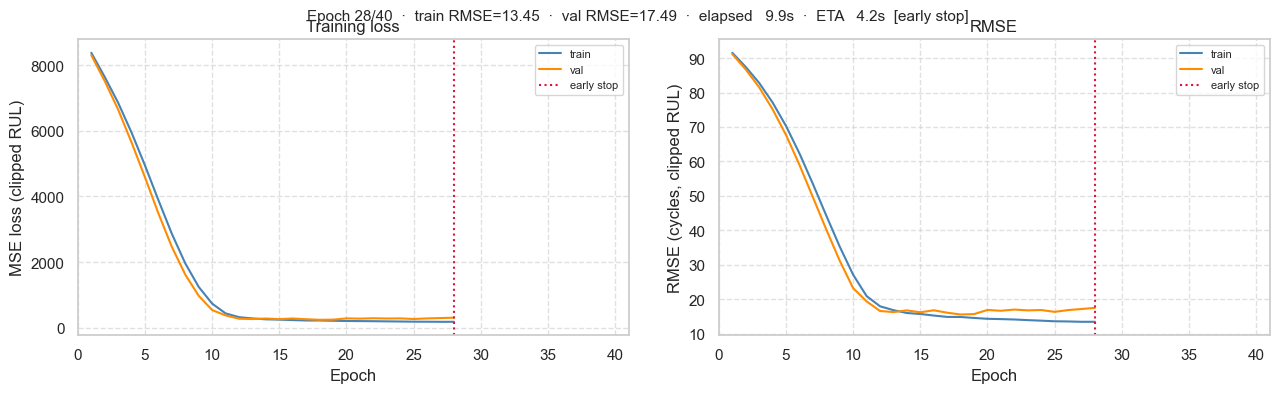

Best val RMSE = 15.563 at epoch 18
Loaded best checkpoint from epoch 18.


In [8]:
BATCH_SIZE = 512
N_EPOCHS   = 40
LR         = 1e-3
PATIENCE   = 10

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=False, num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          drop_last=False, num_workers=0)

model = LSTMRegressor(n_features=len(USE_SENSORS), hidden=64,
                      num_layers=2, dropout=0.3)
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

ckpt_path = CKPT_DIR / f"lstm_v2_{SUBSET}_best.pt"
model, history = train(
    model, train_loader, val_loader,
    n_epochs=N_EPOCHS, lr=LR, patience=PATIENCE,
    device=Device, plot_freq=1, ckpt_path=ckpt_path,
)

## 8 · Final training curves

Static report figure. The dashed vertical line marks the epoch where early stopping fired (if it did); the best-checkpoint epoch is annotated on the val RMSE curve.


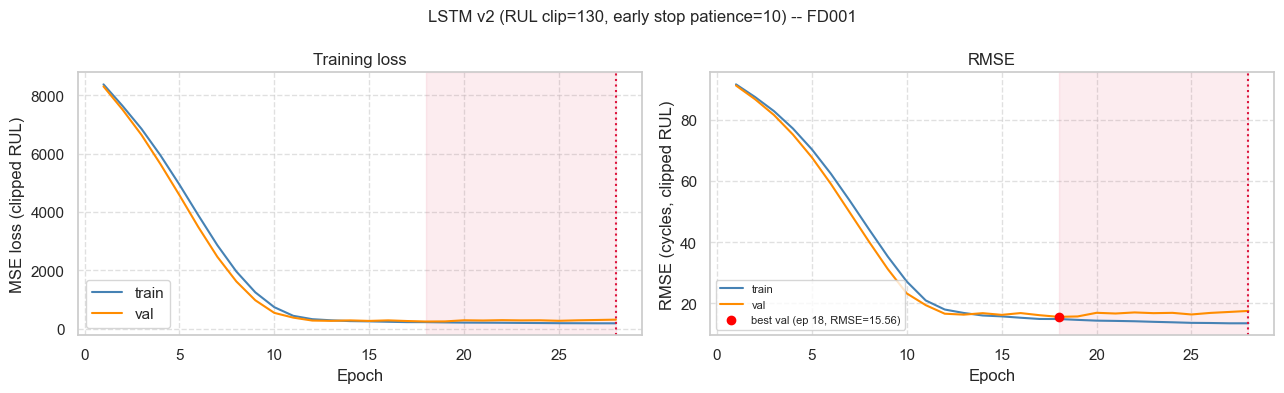

Saved -> figures/lstm_v2_FD001_curves.png


In [9]:
best_epoch_idx = history["val_rmse"].idxmin()
best_epoch_num = history.loc[best_epoch_idx, "epoch"]
best_val_rmse  = history.loc[best_epoch_idx, "val_rmse"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history["epoch"], history["train_loss"], label="train", color="steelblue")
ax1.plot(history["epoch"], history["val_loss"],   label="val",   color="darkorange")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE loss (clipped RUL)")
ax1.set_title("Training loss"); ax1.legend(); ax1.grid(linestyle="--", alpha=0.6)

ax2.plot(history["epoch"], history["train_rmse"], label="train", color="steelblue")
ax2.plot(history["epoch"], history["val_rmse"],   label="val",   color="darkorange")
ax2.scatter([best_epoch_num], [best_val_rmse], color="red", zorder=5,
            label=f"best val (ep {best_epoch_num}, RMSE={best_val_rmse:.2f})")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("RMSE (cycles, clipped RUL)")
ax2.set_title("RMSE"); ax2.legend(fontsize=8); ax2.grid(linestyle="--", alpha=0.6)

# Shade the "patience window" after the best epoch if early stopping fired
stopped_at = history["epoch"].iloc[-1]
if stopped_at < N_EPOCHS:
    for ax in (ax1, ax2):
        ax.axvspan(best_epoch_num, stopped_at, alpha=0.08, color="crimson",
                   label="patience window")
        ax.axvline(stopped_at, color="crimson", linestyle=":", lw=1.5)

plt.suptitle(f"LSTM v2 (RUL clip={RUL_CLIP}, early stop patience={PATIENCE}) -- FD001",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / f"lstm_v2_{SUBSET}_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIG_DIR / f'lstm_v2_{SUBSET}_curves.png'}")

## 9 · Test-set evaluation

Two standard metrics:

1. **RMSE** in cycles (lower is better). Reference: Zheng et al. 2017 LSTM gets ~16.1 on FD001.
2. **Asymmetric score** (PHM 2008) -- penalizes late predictions more heavily than early ones.

Evaluation uses **un-clipped** true labels (clipping is training-only). Predictions are clamped to [0, inf) since negative RUL is physically meaningless.


In [10]:
def asymmetric_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """PHM 2008 asymmetric score: sums exp(-d/13)-1 for early, exp(d/10)-1 for late."""
    d = y_pred - y_true
    return float(np.where(d < 0,
                          np.exp(-d / 13.0) - 1,
                          np.exp( d / 10.0) - 1).sum())


@torch.no_grad()
def predict_test(model, X_test: np.ndarray, device: str, batch_size: int = 256) -> np.ndarray:
    model.eval()
    preds = []
    for i in range(0, len(X_test), batch_size):
        xb = torch.from_numpy(X_test[i:i+batch_size]).to(device)
        preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds)


y_pred_raw = predict_test(model, X_test, Device)
y_pred     = np.clip(y_pred_raw, 0, None)

rmse_test  = math.sqrt(np.mean((y_pred - y_test) ** 2))
score_test = asymmetric_score(y_test, y_pred)
mae_test   = float(np.mean(np.abs(y_pred - y_test)))
bias_test  = float((y_pred - y_test).mean())

print(f"Test RMSE           : {rmse_test:.3f} cycles")
print(f"Test asym. score    : {score_test:.1f}")
print(f"Mean abs error      : {mae_test:.3f} cycles")
print(f"Bias (mean error)   : {bias_test:+.3f} cycles  (positive = late)")
print()
print(f"Reference (Zheng17) : RMSE ~16.1, Score ~339 on FD001")
print(f"v1 baseline         : RMSE 21.05, Score 644, Bias -8.47")

Test RMSE           : 20.702 cycles
Test asym. score    : 663.7
Mean abs error      : 15.796 cycles
Bias (mean error)   : -8.138 cycles  (positive = late)

Reference (Zheng17) : RMSE ~16.1, Score ~339 on FD001
v1 baseline         : RMSE 21.05, Score 644, Bias -8.47


## 10 · Predicted vs true RUL scatter

Each point is one test engine. Points above the diagonal are **late** predictions (dangerous); points below are **early** (safe but pessimistic).


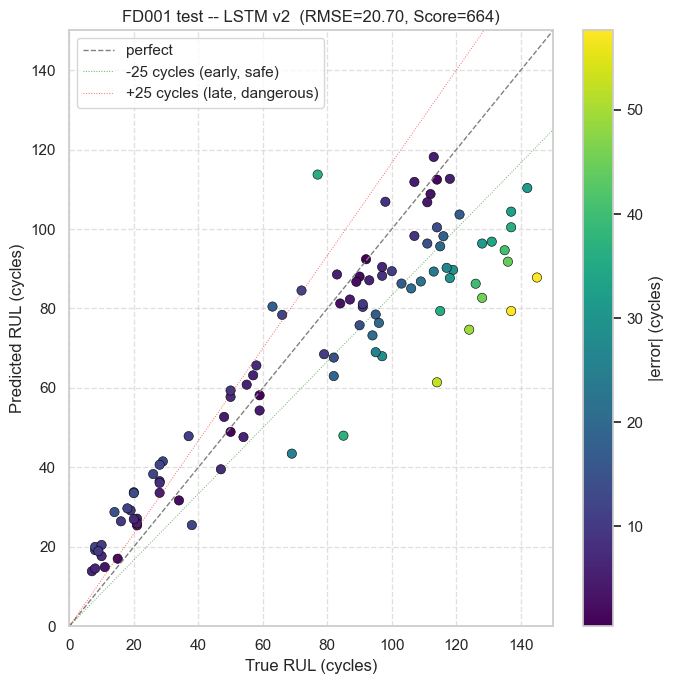

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))

lim = max(y_test.max(), y_pred.max()) + 5
ax.plot([0, lim], [0, lim],      "--", color="gray",  lw=1,   label="perfect")
ax.plot([0, lim], [0, lim - 25], ":",  color="green", lw=0.7, alpha=0.6,
        label="-25 cycles (early, safe)")
ax.plot([0, lim], [0, lim + 25], ":",  color="red",   lw=0.7, alpha=0.6,
        label="+25 cycles (late, dangerous)")

errs = np.abs(y_pred - y_test)
sc = ax.scatter(y_test, y_pred, c=errs, cmap="viridis", s=45,
                edgecolor="black", linewidth=0.4)
plt.colorbar(sc, ax=ax, label="|error| (cycles)")

ax.set_xlabel("True RUL (cycles)")
ax.set_ylabel("Predicted RUL (cycles)")
ax.set_title(f"FD001 test -- LSTM v2  (RMSE={rmse_test:.2f}, Score={score_test:.0f})")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend(loc="upper left")
ax.grid(linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / f"lstm_v2_{SUBSET}_pred_vs_true.png", dpi=150, bbox_inches="tight")
plt.show()

## 11 · Error distribution

Histogram + empirical CDF of signed errors. The bias line shows whether the model is systematically early or late.


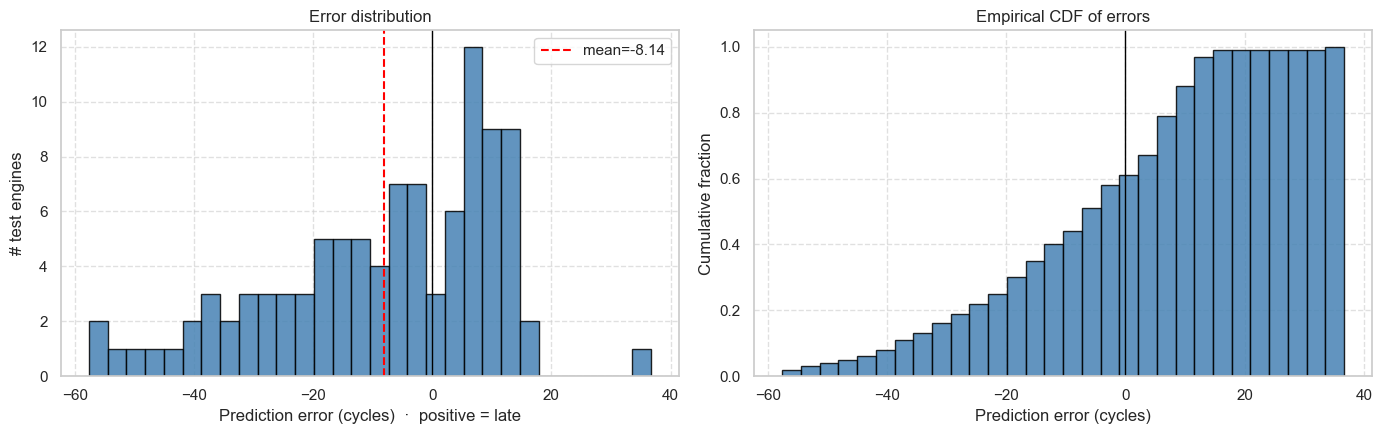

Bias (mean error)     : -8.14 cycles
Std of errors         : 19.04
Fraction of late preds: 41.0%
Fraction within +/-10 : 43.0%


In [12]:
errors = y_pred - y_test  # positive = late, negative = early

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(errors, bins=30, color="steelblue", edgecolor="black", alpha=0.85)
axes[0].axvline(0, color="black", lw=1)
axes[0].axvline(errors.mean(), color="red", linestyle="--",
                label=f"mean={errors.mean():+.2f}")
axes[0].set_xlabel("Prediction error (cycles)  ·  positive = late")
axes[0].set_ylabel("# test engines")
axes[0].set_title("Error distribution")
axes[0].legend()
axes[0].grid(linestyle="--", alpha=0.6)

axes[1].hist(errors, bins=30, color="steelblue", edgecolor="black",
             cumulative=True, density=True, alpha=0.85)
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("Prediction error (cycles)")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("Empirical CDF of errors")
axes[1].grid(linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / f"lstm_v2_{SUBSET}_error_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Bias (mean error)     : {errors.mean():+.2f} cycles")
print(f"Std of errors         : {errors.std():.2f}")
print(f"Fraction of late preds: {(errors > 0).mean():.1%}")
print(f"Fraction within +/-10 : {(np.abs(errors) <= 10).mean():.1%}")

## 12 · Per-engine RUL trajectories

For four selected test engines, we run the model on every sliding window in the trajectory to visualize how the prediction evolves as the engine accumulates more cycles. Engines are chosen to span the range of true RUL values at truncation.


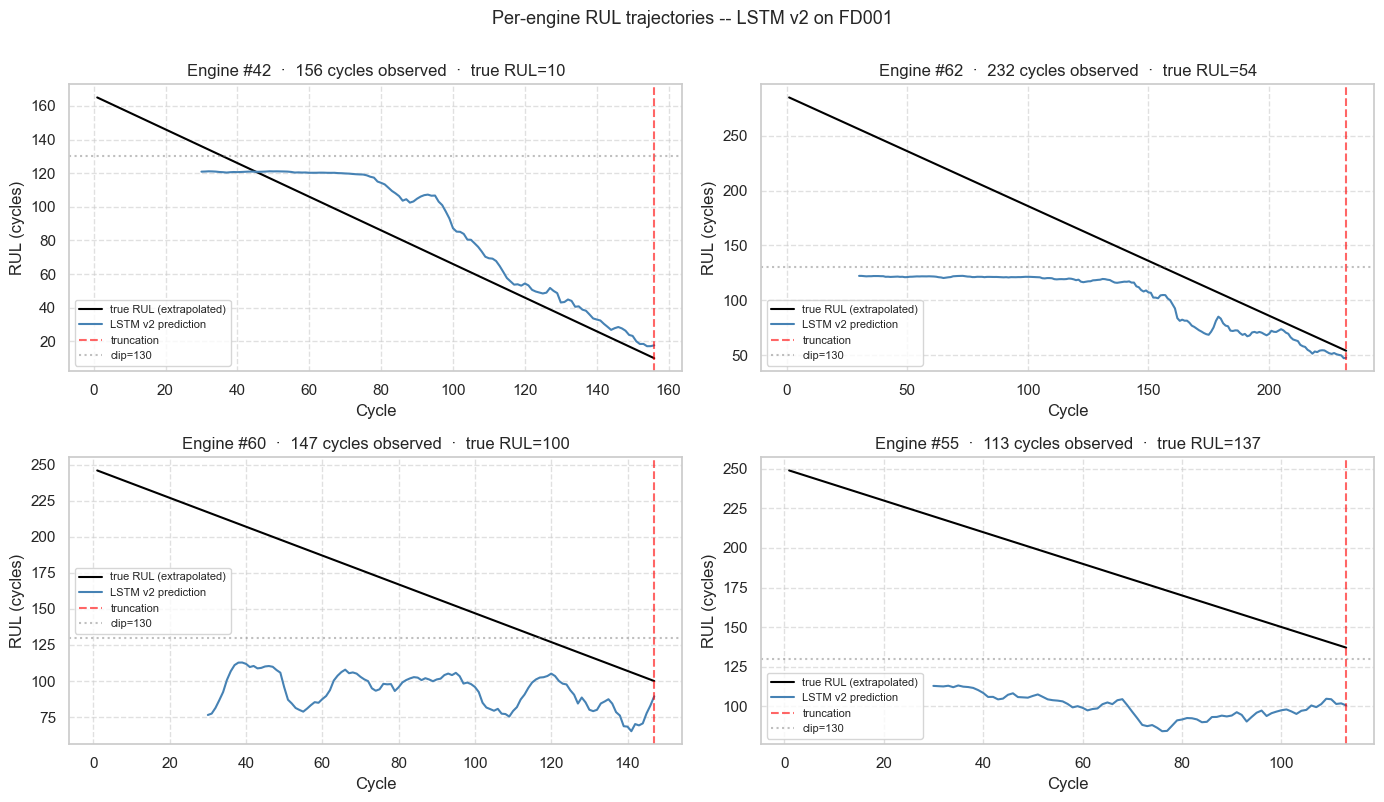

In [13]:
@torch.no_grad()
def predict_engine_trajectory(model, eng_df, sensors, window, device):
    arr = eng_df[sensors].values.astype(np.float32)
    L   = len(arr)
    if L < window:
        return None, None
    Xs    = np.stack([arr[i:i+window] for i in range(L - window + 1)])
    xb    = torch.from_numpy(Xs).to(device)
    preds = model(xb).cpu().numpy()
    cycles_at_pred = np.arange(window, L + 1)
    return cycles_at_pred, preds


order  = np.argsort(y_test)
chosen = [order[5], order[len(order)//3], order[2*len(order)//3], order[-5]]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
model.eval()

for ax, idx in zip(axes, chosen):
    unit = idx + 1
    eng  = test_df[test_df["unit"] == unit]
    cycles_pred, preds = predict_engine_trajectory(model, eng, USE_SENSORS, W, Device)
    if cycles_pred is None:
        continue

    L               = len(eng)
    true_at_last    = y_test[idx]
    cycles          = np.arange(1, L + 1)
    true_rul_extrap = true_at_last + (L - cycles)

    ax.plot(cycles, true_rul_extrap, color="black", lw=1.5,
            label="true RUL (extrapolated)")
    ax.plot(cycles_pred, np.clip(preds, 0, None), color="steelblue", lw=1.5,
            label="LSTM v2 prediction")
    ax.axvline(L, color="red", linestyle="--", alpha=0.6, label="truncation")
    ax.axhline(RUL_CLIP, color="gray", linestyle=":", alpha=0.5,
               label=f"clip={RUL_CLIP}")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("RUL (cycles)")
    ax.set_title(f"Engine #{unit}  ·  {L} cycles observed  ·  true RUL={true_at_last:.0f}")
    ax.legend(fontsize=8)
    ax.grid(linestyle="--", alpha=0.6)

plt.suptitle("Per-engine RUL trajectories -- LSTM v2 on FD001", y=1.00, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / f"lstm_v2_{SUBSET}_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

## 13 · v1 vs v2 comparison

Load the v1 metrics from disk and print a head-to-head table showing the effect of each tightening change. This cell is a no-op if the v1 results JSON is not present.


In [14]:
v1_path = CKPT_DIR / f"lstm_{SUBSET}_results.json"

if v1_path.exists():
    with open(v1_path) as f:
        v1 = json.load(f)

    comparison = pd.DataFrame([
        {"version": "v1 (baseline)",
         "RUL clip": v1.get("rul_clip", 125),
         "early stop": "no",
         "epochs run": v1.get("n_epochs", 60),
         "best val RMSE": v1["best_val_rmse"],
         "test RMSE": v1["test_rmse"],
         "asym score": v1["test_score"]},
        {"version": "v2 (tightened)",
         "RUL clip": RUL_CLIP,
         "early stop": f"yes (p={PATIENCE})",
         "epochs run": int(history["epoch"].iloc[-1]),
         "best val RMSE": float(history["val_rmse"].min()),
         "test RMSE": rmse_test,
         "asym score": score_test},
    ])
    print(comparison.to_string(index=False))
else:
    print("v1 results not found at", v1_path)
    print("v2 results:")
    print(f"  test RMSE  = {rmse_test:.3f}")
    print(f"  asym score = {score_test:.1f}")
    print(f"  epochs run = {int(history['epoch'].iloc[-1])}")

       version  RUL clip early stop  epochs run  best val RMSE  test RMSE  asym score
 v1 (baseline)       125         no          60      14.705620  21.045302  643.976440
v2 (tightened)       130 yes (p=10)          28      15.562568  20.701537  663.674377


## 14 · Save results + summary


In [15]:
history.to_csv(CKPT_DIR / f"lstm_v2_{SUBSET}_history.csv", index=False)

results = {
    "subset":        SUBSET,
    "model":         "LSTM-v2-tightened",
    "n_params":      int(sum(p.numel() for p in model.parameters())),
    "rul_clip":      RUL_CLIP,
    "early_stop_patience": PATIENCE,
    "epochs_run":    int(history["epoch"].iloc[-1]),
    "best_val_epoch": int(history.loc[history["val_rmse"].idxmin(), "epoch"]),
    "best_val_rmse": float(history["val_rmse"].min()),
    "test_rmse":     rmse_test,
    "test_score":    score_test,
    "test_mae":      mae_test,
    "test_bias":     bias_test,
    "batch_size":    BATCH_SIZE,
    "window":        W,
    "n_features":    len(USE_SENSORS),
    "device":        Device,
}

with open(CKPT_DIR / f"lstm_v2_{SUBSET}_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved:")
print(f"  checkpoint : {ckpt_path}")
print(f"  history    : {CKPT_DIR / f'lstm_v2_{SUBSET}_history.csv'}")
print(f"  results    : {CKPT_DIR / f'lstm_v2_{SUBSET}_results.json'}")
print(f"  figures    : {FIG_DIR}/lstm_v2_{SUBSET}_*.png")
print()
print("=" * 60)
print(f"FINAL -- LSTM v2 (tightened baseline) on {SUBSET}")
print("=" * 60)
for k, v in results.items():
    if isinstance(v, float):
        print(f"  {k:<25}: {v:.3f}")
    else:
        print(f"  {k:<25}: {v}")

Saved:
  checkpoint : checkpoints/lstm_v2_FD001_best.pt
  history    : checkpoints/lstm_v2_FD001_history.csv
  results    : checkpoints/lstm_v2_FD001_results.json
  figures    : figures/lstm_v2_FD001_*.png

FINAL -- LSTM v2 (tightened baseline) on FD001
  subset                   : FD001
  model                    : LSTM-v2-tightened
  n_params                 : 55873
  rul_clip                 : 130
  early_stop_patience      : 10
  epochs_run               : 28
  best_val_epoch           : 18
  best_val_rmse            : 15.563
  test_rmse                : 20.702
  test_score               : 663.674
  test_mae                 : 15.796
  test_bias                : -8.138
  batch_size               : 512
  window                   : 30
  n_features               : 14
  device                   : mps


## Next steps

This v2 tightened baseline is the number every other model has to beat. Two contributions in separate notebooks:

1. **`modeling_v3_transformer.ipynb`** -- same data pipeline, swap LSTM for a small encoder-only Transformer (2-4 layers, 4 heads, model dim 64). Train on FD001. Compare RMSE/score head-to-head against v2.
2. **`modeling_v4_dann.ipynb`** -- keep the LSTM encoder, add a domain classifier head through a Gradient Reversal Layer (Ganin et al. 2016). Train with labeled FD001 + unlabeled FD002. Evaluate on FD002 test set against:
   - Lower bound: this v2 LSTM (FD001-trained) evaluated naively on FD002.
   - Upper bound: an LSTM trained directly on labeled FD002.

The DANN story: how much of the FD001 -> FD002 generalization gap can domain-adversarial training close using only unlabeled target data?
